# **Persiapan Dataset dan Validasi Awal**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 63.7 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import ultralytics

print(ultralytics.__version__)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
8.3.237


In [ ]:
PROJECT_ROOT = "/content/drive/MyDrive/TA_KopiRobusta_YOLOv8"

import os
os.makedirs(PROJECT_ROOT, exist_ok=True)

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/TUGAS_AKHIR/Dataset"

In [ ]:
import os
dataset_path = "/content/drive/MyDrive/TUGAS_AKHIR/Dataset"
os.listdir(dataset_path)

['data.yaml',
 'README.roboflow.txt',
 'README.dataset.txt',
 'train',
 'valid',
 'test']

In [ ]:
for split in ["train", "valid", "test"]:
    print(f"\nIsi folder {split}:")
    print(os.listdir(f"{DATASET_PATH}/{split}"))


Isi folder train:
['labels', 'images']

Isi folder valid:
['images', 'labels']

Isi folder test:
['images', 'labels']


In [ ]:
with open("/content/drive/MyDrive/TUGAS_AKHIR/Dataset/data.yaml", "r") as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names: ['matang', 'mentah', 'setengah-matang']

roboflow:
  workspace: alfito-dwi-putra
  project: coffee-dataset-2
  version: 5
  license: CC BY 4.0
  url: https://universe.roboflow.com/alfito-dwi-putra/coffee-dataset-2/dataset/5


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

# path images dan labels
IMG_DIR = f"{DATASET_PATH}/train/images"
LBL_DIR = f"{DATASET_PATH}/train/labels"

# ambil 1 file contoh
img_file = os.listdir(IMG_DIR)[0]
lbl_file = img_file.replace(".jpg", ".txt").replace(".png", ".txt")

img_path = os.path.join(IMG_DIR, img_file)
lbl_path = os.path.join(LBL_DIR, lbl_file)

img_file, lbl_file

('20240324_120602_jpg.rf.9285e809187ba7583f5d96d1db857492.jpg',
 '20240324_120602_jpg.rf.9285e809187ba7583f5d96d1db857492.txt')

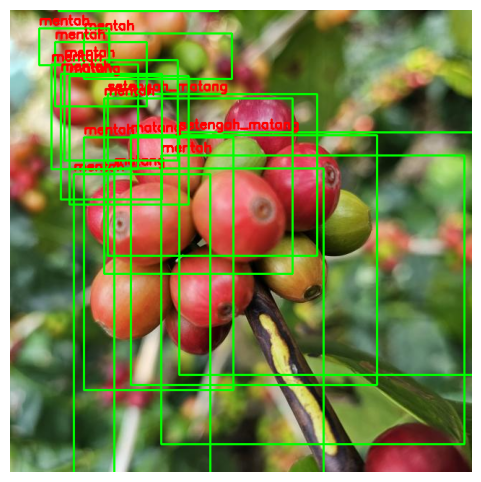

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

IMG_DIR = f"{DATASET_PATH}/train/images"
LBL_DIR = f"{DATASET_PATH}/train/labels"

img_file = os.listdir(IMG_DIR)[0]
lbl_file = img_file.replace(".jpg", ".txt")

img = cv2.imread(os.path.join(IMG_DIR, img_file))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img.shape

class_names = ["matang", "setengah_matang", "mentah"]

with open(os.path.join(LBL_DIR, lbl_file)) as f:
    for line in f:
        parts = line.split()
        cls, x, y, bw, bh = map(float, parts[:5])

        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)
        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)

        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(img, class_names[int(cls)],
                    (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, (255,0,0), 2)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()

# **Baseline**

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/drive/MyDrive/TUGAS_AKHIR/Dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project="/content/drive/MyDrive/TA_KopiRobusta_YOLOv8",
    name="baseline",
    device="0"
)

Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/TUGAS_AKHIR/Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f4f361d8c20>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
# Load model terbaik
best_model_path = "/content/drive/MyDrive/TA_KopiRobusta_YOLOv8/baseline/weights/best.pt"
model = YOLO(best_model_path)

# Evaluasi otomatis
metrics = model.val(
    data="/content/drive/MyDrive/TUGAS_AKHIR/Dataset/data.yaml"
)

# Ambil nilai
precision = metrics.box.mp
recall = metrics.box.mr
map50 = metrics.box.map50
map5095 = metrics.box.map

# Tampilkan
print("=== BASELINE METRICS ===")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"mAP50       : {map50:.4f}")
print(f"mAP50-95    : {map5095:.4f}")

Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.6 ms, read: 14.1±8.4 MB/s, size: 51.1 KB)
val: Scanning /content/drive/MyDrive/TUGAS_AKHIR/Dataset/valid/labels.cache... 394 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 394/394 494.6Kit/s 0.0s
val: /content/drive/MyDrive/TUGAS_AKHIR/Dataset/valid/images/20240324_092200_jpg.rf.1547ab2daaa18dc97a505bb3559ab54a.jpg: 1 duplicate labels removed
val: /content/drive/MyDrive/TUGAS_AKHIR/Dataset/valid/images/20240324_110011_jpg.rf.b4691e4df13ccb82557c600f4d27a076.jpg: 1 duplicate labels removed
val: /content/drive/MyDrive/TUGAS_AKHIR/Dataset/valid/images/20240324_125457_jpg.rf.c6086bbc299d662734d7bab246f9629b.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 2.7it/s 9.1s
                   all  

# **Learning Rate**

In [ ]:
from ultralytics import YOLO
import csv

DATA_YAML = "/content/drive/MyDrive/TUGAS_AKHIR/Dataset/data.yaml"
PROJECT_ROOT = "/content/drive/MyDrive/TA_KopiRobusta_YOLOv8"
COARSE_DIR = f"{PROJECT_ROOT}/coarse_lr0"

results = []

for lr in [0.001, 0.01, 0.1]:
    print(f"\n=== Training lr0 = {lr} ===")

    model = YOLO("yolov8n.pt")

    model.train(
        data=DATA_YAML,
        epochs=30,
        imgsz=640,
        batch=16,
        lr0=lr,
        project=COARSE_DIR,
        name=f"lr0_{lr}",
        device=0
    )

    # evaluasi otomatis
    metrics = model.val(data=DATA_YAML)

    results.append([
        lr,
        metrics.box.mp,
        metrics.box.mr,
        metrics.box.map50,
        metrics.box.map
    ])

# simpan hasil
csv_path = f"{COARSE_DIR}/coarse_lr0_results.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["lr0", "Precision", "Recall", "mAP50", "mAP50-95"])
    writer.writerows(results)

print("Hasil coarse search disimpan di:", csv_path)


=== Training lr0 = 0.001 ===
Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/TUGAS_AKHIR/Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=lr0_0.001, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

Analisis Hasil lr0

In [ ]:
import pandas as pd

csv_path = "/content/drive/MyDrive/TA_KopiRobusta_YOLOv8/coarse_lr0/coarse_lr0_results.csv"
df = pd.read_csv(csv_path)

df

,lr0,Precision,Recall,mAP50,mAP50-95
0,0.001,0.695148,0.794684,0.813687,0.780756
1,0.010,0.695148,0.794684,0.813687,0.780756
2,0.100,0.695148,0.794684,0.813687,0.780756


# **IMGSZ**

In [ ]:
from ultralytics import YOLO

img_sizes = [320, 640, 800]

for imgsz in img_sizes:
    model = YOLO("yolov8n.pt")

    model.train(
        data="/content/drive/MyDrive/TUGAS_AKHIR/Dataset/data.yaml",
        epochs=50,
        imgsz=imgsz,
        batch=16,
        project="/content/drive/MyDrive/TA_KopiRobusta_YOLOv8/imgsz",
        name=f"imgsz_{imgsz}",
        device="0"
    )

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.239 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/TUGAS_AKHIR/Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=Fa

In [ ]:
import pandas as pd
import os

BASE_DIR = "/content/drive/MyDrive/TA_KopiRobusta_YOLOv8/imgsz"

imgsz_runs = {
    320: os.path.join(BASE_DIR, "imgsz_320", "results.csv"),
    640: os.path.join(BASE_DIR, "imgsz_640", "results.csv"),
    800: os.path.join(BASE_DIR, "imgsz_800", "results.csv"),
}

In [ ]:
results = []

for imgsz, csv_path in imgsz_runs.items():
    if not os.path.exists(csv_path):
        print(f"❌ File tidak ditemukan: {csv_path}")
        continue

    df = pd.read_csv(csv_path)

    # ambil epoch terakhir
    last = df.iloc[-1]

    results.append({
        "imgsz": imgsz,
        "Precision": last["metrics/precision(B)"],
        "Recall": last["metrics/recall(B)"],
        "mAP50": last["metrics/mAP50(B)"],
        "mAP50-95": last["metrics/mAP50-95(B)"]
    })

In [ ]:
results_df = pd.DataFrame(results).sort_values("imgsz")
results_df

,imgsz,Precision,Recall,mAP50,mAP50-95
0,320,0.71035,0.75171,0.79289,0.73211
1,640,0.71118,0.75073,0.80122,0.76990
2,800,0.68120,0.78055,0.79674,0.77070


# **BATCH**

In [ ]:
from ultralytics import YOLO

BEST_IMGSZ = 640
batch_sizes = [8, 16, 32]

for batch in batch_sizes:
    model = YOLO("yolov8n.pt")

    model.train(
        data="/content/drive/MyDrive/TUGAS_AKHIR/Dataset/data.yaml",
        epochs=50,
        imgsz=BEST_IMGSZ,
        batch=batch,
        project="/content/drive/MyDrive/TA_KopiRobusta_YOLOv8/batch",
        name=f"batch_{batch}",
        device="0",
        exist_ok=True
    )

Ultralytics 8.3.239 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/TUGAS_AKHIR/Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=batch_8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.

In [ ]:
import pandas as pd
import os
BASE_DIR = "/content/drive/MyDrive/TA_KopiRobusta_YOLOv8/batch"

batch_runs = {
    8:  os.path.join(BASE_DIR, "batch_8", "results.csv"),
    16: os.path.join(BASE_DIR, "batch_16", "results.csv"),
    32: os.path.join(BASE_DIR, "batch_32", "results.csv"),
}
results = []

for batch, csv_path in batch_runs.items():
    if not os.path.exists(csv_path):
        print(f"❌ File tidak ditemukan: {csv_path}")
        continue

    df = pd.read_csv(csv_path)
    last = df.iloc[-1]

    results.append({
        "batch": batch,
        "Precision": last["metrics/precision(B)"],
        "Recall": last["metrics/recall(B)"],
        "mAP50": last["metrics/mAP50(B)"],
        "mAP50-95": last["metrics/mAP50-95(B)"]
    })

In [ ]:
results_df = pd.DataFrame(results).sort_values("batch")
results_df

,batch,Precision,Recall,mAP50,mAP50-95
0,8,0.70518,0.77909,0.80592,0.77517
1,16,0.71118,0.75073,0.80122,0.76990
2,32,0.71811,0.75294,0.79973,0.76960


In [ ]:
best_row = results_df.loc[results_df["mAP50-95"].idxmax()]
best_row

,0
batch,8.00000
Precision,0.70518
Recall,0.77909
mAP50,0.80592
mAP50-95,0.77517


# **OPTIMIZER**

In [ ]:
from ultralytics import YOLO

IMG_SIZE = 640
BATCH_SIZE = 8
EPOCHS = 50

optimizers = ["SGD", "AdamW"]

for opt in optimizers:
    model = YOLO("yolov8n.pt")

    model.train(
        data="/content/drive/MyDrive/TUGAS_AKHIR/Dataset/data.yaml",
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        optimizer=opt,
        project="/content/drive/MyDrive/TA_KopiRobusta_YOLOv8/optimizer",
        name=opt,
        device="cpu",
        exist_ok=True
    )

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.239 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/TUGAS_AKHIR/Dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=F

In [ ]:
from ultralytics import YOLO

IMG_SIZE = 640
BATCH_SIZE = 8
EPOCHS = 50

optimizers = ["AdamW"]

for opt in optimizers:
    model = YOLO("yolov8n.pt")

    model.train(
        data="/content/drive/MyDrive/TUGAS_AKHIR/Dataset/data.yaml",
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        optimizer=opt,
        project="/content/drive/MyDrive/TA_KopiRobusta_YOLOv8/optimizer",
        name=opt,
        device="0",
        exist_ok=True
    )

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.239 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/TUGAS_AKHIR/Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=Fals

In [ ]:
import pandas as pd
import os

BASE_DIR = "/content/drive/MyDrive/TA_KopiRobusta_YOLOv8/optimizer"

opt_runs = {
    "SGD": os.path.join(BASE_DIR, "SGD", "results.csv"),
    "AdamW": os.path.join(BASE_DIR, "AdamW", "results.csv"),
}

results = []

for opt, csv_path in opt_runs.items():
    if not os.path.exists(csv_path):
        print(f"❌ File tidak ditemukan: {csv_path}")
        continue

    df = pd.read_csv(csv_path)
    last = df.iloc[-1]

    results.append({
        "Optimizer": opt,
        "Precision": last["metrics/precision(B)"],
        "Recall": last["metrics/recall(B)"],
        "mAP50": last["metrics/mAP50(B)"],
        "mAP50-95": last["metrics/mAP50-95(B)"]
    })

results_df = pd.DataFrame(results)
results_df

,Optimizer,Precision,Recall,mAP50,mAP50-95
0,SGD,0.70773,0.76450,0.80689,0.77076
1,AdamW,0.71869,0.76911,0.82032,0.78729


# **TRAIN FINAL**

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/drive/MyDrive/TUGAS_AKHIR/Dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    optimizer="AdamW",
    project="/content/drive/MyDrive/TA_KopiRobusta_YOLOv8/final_model",
    name="yolov8n_final",
    device="0",
    exist_ok=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/TUGAS_AKHIR/Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=6

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c046421f680>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

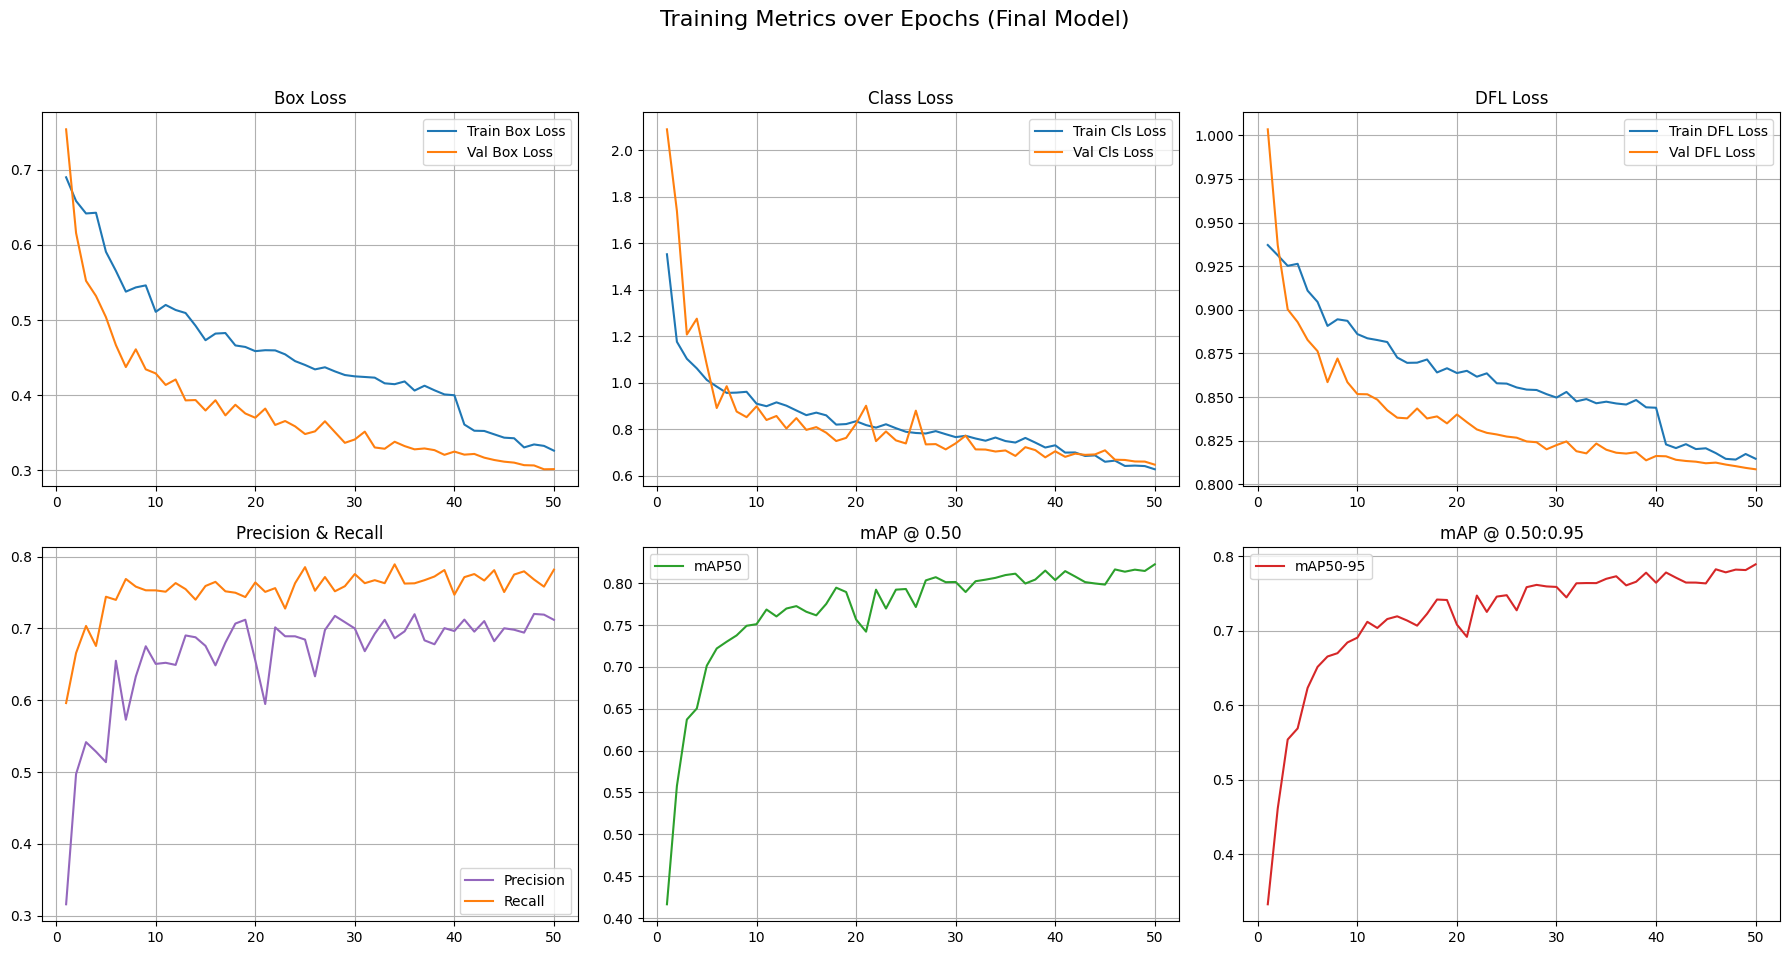

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Path to the results.csv of the final model
results_path = "/content/drive/MyDrive/TA_KopiRobusta_YOLOv8/final_model/yolov8n_final/results.csv"

if os.path.exists(results_path):
    # Load data
    df = pd.read_csv(results_path)

    # Strip whitespace from column names
    df.columns = df.columns.str.strip()

    # Create subplots
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Training Metrics over Epochs (Final Model)', fontsize=16)

    # Plot Losses
    axs[0, 0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
    axs[0, 0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
    axs[0, 0].set_title('Box Loss')
    axs[0, 0].legend()
    axs[0, 0].grid(True)

    axs[0, 1].plot(df['epoch'], df['train/cls_loss'], label='Train Cls Loss')
    axs[0, 1].plot(df['epoch'], df['val/cls_loss'], label='Val Cls Loss')
    axs[0, 1].set_title('Class Loss')
    axs[0, 1].legend()
    axs[0, 1].grid(True)

    axs[0, 2].plot(df['epoch'], df['train/dfl_loss'], label='Train DFL Loss')
    axs[0, 2].plot(df['epoch'], df['val/dfl_loss'], label='Val DFL Loss')
    axs[0, 2].set_title('DFL Loss')
    axs[0, 2].legend()
    axs[0, 2].grid(True)

    # Plot Metrics
    axs[1, 0].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='tab:purple')
    axs[1, 0].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='tab:orange')
    axs[1, 0].set_title('Precision & Recall')
    axs[1, 0].legend()
    axs[1, 0].grid(True)

    axs[1, 1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50', color='tab:green')
    axs[1, 1].set_title('mAP @ 0.50')
    axs[1, 1].legend()
    axs[1, 1].grid(True)

    axs[1, 2].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95', color='tab:red')
    axs[1, 2].set_title('mAP @ 0.50:0.95')
    axs[1, 2].legend()
    axs[1, 2].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print(f"File not found: {results_path}")

# **Validation**

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/TA_KopiRobusta_YOLOv8/final_model/yolov8n_final/weights/best.pt")

model.val(
    data="/content/drive/MyDrive/TUGAS_AKHIR/Dataset/data.yaml",
    imgsz=640,
    batch=8,
    project="/content/drive/MyDrive/TA_KopiRobusta_YOLOv8/evaluation",
    name="validation",
    exist_ok=True
)

Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 1.0±1.5 ms, read: 22.5±13.1 MB/s, size: 53.1 KB)
val: Scanning /content/drive/MyDrive/TUGAS_AKHIR/Dataset/valid/labels.cache... 394 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 394/394 515.9Kit/s 0.0s
val: /content/drive/MyDrive/TUGAS_AKHIR/Dataset/valid/images/20240324_092200_jpg.rf.1547ab2daaa18dc97a505bb3559ab54a.jpg: 1 duplicate labels removed
val: /content/drive/MyDrive/TUGAS_AKHIR/Dataset/valid/images/20240324_110011_jpg.rf.b4691e4df13ccb82557c600f4d27a076.jpg: 1 duplicate labels removed
val: /content/drive/MyDrive/TUGAS_AKHIR/Dataset/valid/images/20240324_125457_jpg.rf.c6086bbc299d662734d7bab246f9629b.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 12.9it/s 3.9s
         

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c03e3ca4680>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

# **TESTING**

In [ ]:
model.val(
    data="/content/drive/MyDrive/TUGAS_AKHIR/Dataset/data.yaml",
    split="test",
    imgsz=640,
    batch=8,
    project="/content/drive/MyDrive/TA_KopiRobusta_YOLOv8/evaluation",
    name="test",
    exist_ok=True
)

Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
val: Fast image access ✅ (ping: 1.0±0.9 ms, read: 12.8±11.5 MB/s, size: 48.5 KB)
val: Scanning /content/drive/MyDrive/TUGAS_AKHIR/Dataset/test/labels.cache... 196 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 196/196 239.7Kit/s 0.0s
val: /content/drive/MyDrive/TUGAS_AKHIR/Dataset/test/images/20240324_090819_jpg.rf.ca5cbeb40a306f75a1cec535b0652acd.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 8.8it/s 2.8s
                   all        196       2104      0.723      0.781      0.825      0.793
                matang        131        740      0.675      0.703      0.733      0.713
                mentah        134        648      0.751      0.821      0.873      0.844
       setengah-matang        132        716      0.743      0.819       0.87      0.822
Speed: 1.3ms preprocess, 2.8ms inf

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c03fa5f90d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

# **REAL CASE**

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/TA_KopiRobusta_YOLOv8/final_model/yolov8n_final/weights/best.pt")

model.predict(
    source="/content/drive/MyDrive/TUGAS_AKHIR/Dataset_Robusta_Ijen/",
    imgsz=640,
    conf=0.25,
    save=True,
    project="/content/drive/MyDrive/TA_KopiRobusta_YOLOv8/real_case",
    name="inference",
    exist_ok=True
)


image 1/25 /content/drive/MyDrive/TUGAS_AKHIR/Dataset_Robusta_Ijen/1.jpg: 640x384 2 setengah-matangs, 142.4ms
image 2/25 /content/drive/MyDrive/TUGAS_AKHIR/Dataset_Robusta_Ijen/10.jpg: 640x384 2 setengah-matangs, 7.9ms
image 3/25 /content/drive/MyDrive/TUGAS_AKHIR/Dataset_Robusta_Ijen/11.jpg: 640x384 13 matangs, 2 mentahs, 5 setengah-matangs, 8.0ms
image 4/25 /content/drive/MyDrive/TUGAS_AKHIR/Dataset_Robusta_Ijen/12.jpg: 640x384 7 matangs, 2 mentahs, 3 setengah-matangs, 7.8ms
image 5/25 /content/drive/MyDrive/TUGAS_AKHIR/Dataset_Robusta_Ijen/13.jpg: 640x384 (no detections), 7.8ms
image 6/25 /content/drive/MyDrive/TUGAS_AKHIR/Dataset_Robusta_Ijen/14.jpg: 640x384 51 matangs, 6 mentahs, 49 setengah-matangs, 8.3ms
image 7/25 /content/drive/MyDrive/TUGAS_AKHIR/Dataset_Robusta_Ijen/15.jpg: 640x384 37 matangs, 5 mentahs, 15 setengah-matangs, 7.8ms
image 8/25 /content/drive/MyDrive/TUGAS_AKHIR/Dataset_Robusta_Ijen/16.jpg: 640x384 33 matangs, 2 mentahs, 6 setengah-matangs, 8.3ms
image 9/25 /c

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'matang', 1: 'mentah', 2: 'setengah-matang'}
 obb: None
 orig_img: array([[[216, 239, 217],
         [195, 221, 198],
         [178, 206, 183],
         ...,
         [115, 108,  89],
         [119, 112,  93],
         [123, 116,  97]],
 
        [[210, 233, 211],
         [187, 213, 190],
         [169, 197, 174],
         ...,
         [115, 108,  89],
         [119, 112,  93],
         [123, 116,  97]],
 
        [[202, 224, 200],
         [177, 201, 177],
         [156, 182, 158],
         ...,
         [115, 108,  89],
         [119, 112,  93],
         [123, 116,  97]],
 
        ...,
 
        [[134, 131, 123],
         [134, 131, 123],
         [135, 132, 124],
         ...,
         [231, 225, 214],
         [234, 230, 219],
         [238, 234, 223]],
 
        [[132, 130, 122],
         [133, 131, 123],
         [134, 132, 124

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/TA_KopiRobusta_YOLOv8/final_model/yolov8n_final/weights/best.pt")

model.predict(
    source="/content/drive/MyDrive/TUGAS_AKHIR/Dataset_Robusta_Ijen/",
    imgsz=640,
    conf=0.25,
    save=True,
    save_txt=True,
    project="/content/drive/MyDrive/TA_KopiRobusta_YOLOv8/real_case",
    name="inference_graph",
    exist_ok=True
)


image 1/25 /content/drive/MyDrive/TUGAS_AKHIR/Dataset_Robusta_Ijen/1.jpg: 640x384 2 setengah-matangs, 10.5ms
image 2/25 /content/drive/MyDrive/TUGAS_AKHIR/Dataset_Robusta_Ijen/10.jpg: 640x384 2 setengah-matangs, 7.9ms
image 3/25 /content/drive/MyDrive/TUGAS_AKHIR/Dataset_Robusta_Ijen/11.jpg: 640x384 13 matangs, 2 mentahs, 5 setengah-matangs, 7.8ms
image 4/25 /content/drive/MyDrive/TUGAS_AKHIR/Dataset_Robusta_Ijen/12.jpg: 640x384 7 matangs, 2 mentahs, 3 setengah-matangs, 7.8ms
image 5/25 /content/drive/MyDrive/TUGAS_AKHIR/Dataset_Robusta_Ijen/13.jpg: 640x384 (no detections), 8.2ms
image 6/25 /content/drive/MyDrive/TUGAS_AKHIR/Dataset_Robusta_Ijen/14.jpg: 640x384 51 matangs, 6 mentahs, 49 setengah-matangs, 7.7ms
image 7/25 /content/drive/MyDrive/TUGAS_AKHIR/Dataset_Robusta_Ijen/15.jpg: 640x384 37 matangs, 5 mentahs, 15 setengah-matangs, 7.8ms
image 8/25 /content/drive/MyDrive/TUGAS_AKHIR/Dataset_Robusta_Ijen/16.jpg: 640x384 33 matangs, 2 mentahs, 6 setengah-matangs, 7.8ms
image 9/25 /co

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'matang', 1: 'mentah', 2: 'setengah-matang'}
 obb: None
 orig_img: array([[[216, 239, 217],
         [195, 221, 198],
         [178, 206, 183],
         ...,
         [115, 108,  89],
         [119, 112,  93],
         [123, 116,  97]],
 
        [[210, 233, 211],
         [187, 213, 190],
         [169, 197, 174],
         ...,
         [115, 108,  89],
         [119, 112,  93],
         [123, 116,  97]],
 
        [[202, 224, 200],
         [177, 201, 177],
         [156, 182, 158],
         ...,
         [115, 108,  89],
         [119, 112,  93],
         [123, 116,  97]],
 
        ...,
 
        [[134, 131, 123],
         [134, 131, 123],
         [135, 132, 124],
         ...,
         [231, 225, 214],
         [234, 230, 219],
         [238, 234, 223]],
 
        [[132, 130, 122],
         [133, 131, 123],
         [134, 132, 124